<a href="https://colab.research.google.com/github/kham3465/Mesh3d/blob/main/Copy_of_demo_3ddfa_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## A simple demostration of how to run

In [ ]:
# if not clone, clone it
%cd /content
!git clone https://github.com/cleardusk/3DDFA_V2.git
%cd 3DDFA_V2

/content
Cloning into '3DDFA_V2'...
remote: Enumerating objects: 706, done.
remote: Counting objects: 100% (266/266), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 706 (delta 219), reused 204 (delta 204), pack-reused 440 (from 1)
Receiving objects: 100% (706/706), 74.77 MiB | 15.03 MiB/s, done.
Resolving deltas: 100% (378/378), done.
/content/3DDFA_V2


In [ ]:
# cleaning
# %rm -rf /content/3DDFA_V2
!pwd
!ls FaceBoxes/utils/nms/*.so

/content/3DDFA_V2
ls: cannot access 'FaceBoxes/utils/nms/*.so': No such file or directory


In [ ]:
!sed -i 's/np.int_t/int/g' FaceBoxes/utils/nms/cpu_nms.pyx
!pip install "numpy<2.0.0"
!pip install onnxscript onnx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 96.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 15.8 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
^C


In [ ]:
!sh ./build.sh

sh: 0: cannot open ./build.sh: No such file


In [ ]:
# before import, make sure FaceBoxes and Sim3DR are built successfully, e.g.,

import cv2
import yaml

from FaceBoxes import FaceBoxes
from TDDFA import TDDFA
from utils.render import render
from utils.depth import depth
from utils.pncc import pncc
from utils.uv import uv_tex
from utils.pose import viz_pose
from utils.serialization import ser_to_ply, ser_to_obj
from utils.functions import draw_landmarks, get_suffix

import matplotlib.pyplot as plt
from skimage import io
!pip install onnxscript onnx

  Using cached onnxscript-0.6.2-py3-none-any.whl.metadata (13 kB)
  Using cached onnx-1.21.0-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.5 kB)
  Using cached onnx_ir-0.2.0-py3-none-any.whl.metadata (3.3 kB)
Using cached onnxscript-0.6.2-py3-none-any.whl (689 kB)
Using cached onnx-1.21.0-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (17.6 MB)
Using cached onnx_ir-0.2.0-py3-none-any.whl (164 kB)


### Load configs

In [ ]:
%cd /content/3DDFA_V2
# Cài đặt lại thư viện nếu máy báo thiếu (thường Colab sẽ giữ lại disk nhưng mất ram)
!pip install -r requirements.txt
# Chạy build để đảm bảo các file .so đã sẵn sàng
!sh build.sh

/content/3DDFA_V2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 77.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.


Compiling nms/cpu_nms.pyx because it changed.
[1/1] Cythonizing nms/cpu_nms.pyx
/usr/local/lib/python3.12/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/3DDFA_V2/FaceBoxes/utils/nms/cpu_nms.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)
nms/cpu_nms.c: In function ‘__pyx_pf_3nms_7cpu_nms_2cpu_soft_nms’:
nms/cpu_nms.c:6688:32: warning: comparison of integer expressions of different signedness: ‘int’ and ‘unsigned int’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wsign-compare-Wsign-compare]8;;]
 6688 |       __pyx_t_8 = (__pyx_v_pos < __pyx_v_N);
      |                                ^
nms/cpu_nms.c:7199:32: warning: comparison of integer expressions of different signedness: ‘int’ and ‘unsigned int’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wsign-compare-Wsign-compare]8;;]
 7199 |       __

In [ ]:
%cd /content/3DDFA_V2
!pip install Cyclone
!sh build.sh

import os
import sys
sys.path.append('/content/3DDFA_V2')

import yaml
from FaceBoxes import FaceBoxes
from TDDFA import TDDFA

cfg = yaml.load(open('configs/mb1_120x120.yml'), Loader=yaml.SafeLoader)
face_boxes = FaceBoxes()
tddfa = TDDFA(gpu_mode=True, **cfg)

/content/3DDFA_V2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 5.0 MB/s eta 0:00:00
  Using cached incremental-24.11.0-py3-none-any.whl.metadata (9.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.4/200.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 7.4 MB/s eta 0:00:00
Using cached incremental-24.11.0-py3-none-any.whl (21 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 25.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates fro

/content/3DDFA_V2/utils/io.py:28: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(open(fp, 'rb'))


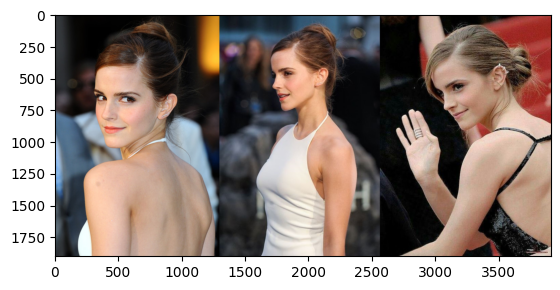

In [ ]:
# given an image path or the image url

# img_fp = 'examples/inputs/emma.jpg'
# img = cv2.imread(img_fp)
# plt.imshow(img[..., ::-1])

img_url = 'https://raw.githubusercontent.com/cleardusk/3DDFA_V2/master/examples/inputs/emma.jpg'
img = io.imread(img_url)
plt.imshow(img)

img = img[..., ::-1]  # RGB -> BGR

### Detect faces using FaceBoxes

In [ ]:
import numpy as np
import FaceBoxes.utils.nms_wrapper as nms_wrapper

def nms_numpy(dets, thresh):
    x1 = dets[:, 0]
    y1 = dets[:, 1]
    x2 = dets[:, 2]
    y2 = dets[:, 3]
    scores = dets[:, 4]

    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1 + 1)
        h = np.maximum(0.0, yy2 - yy1 + 1)
        inter = w * h
        ovr = inter / (areas[i] + areas[order[1:]] - inter)

        inds = np.where(ovr <= thresh)[0]
        order = order[inds + 1]

    return keep

nms_wrapper.nms = nms_numpy
nms_wrapper.cpu_nms = nms_numpy

boxes = face_boxes(img_bgr)
print(f'Detect {len(boxes)} faces')
print(boxes)

Detect 3 faces
[[np.float32(1699.8129), np.float32(278.49893), np.float32(2057.769), np.float32(762.4346), np.float32(0.9999492)], [np.float32(2999.3958), np.float32(304.86737), np.float32(3428.6719), np.float32(900.9679), np.float32(0.999895)], [np.float32(317.27075), np.float32(399.8363), np.float32(792.7346), np.float32(1048.3191), np.float32(0.99988747)]]


### Regressing 3DMM parameters, reconstruction and visualization

In [ ]:
# regress 3DMM params
param_lst, roi_box_lst = tddfa(img, boxes)

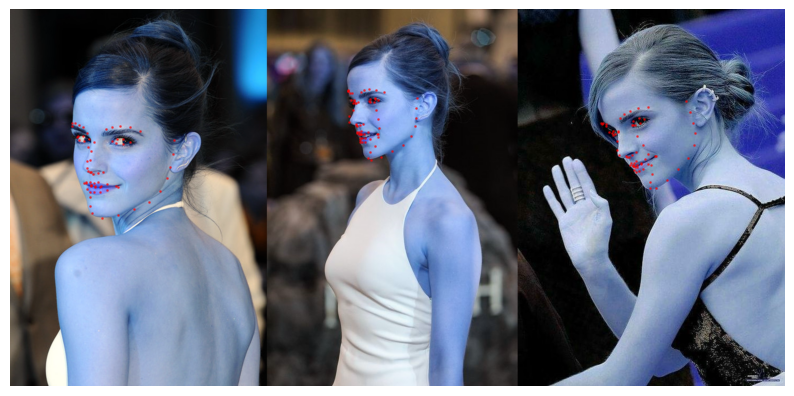

In [ ]:
import sys
import os
import matplotlib.pyplot as plt

vis_path = !find /content/3DDFA_V2 -name "vis.py"

if vis_path:
    dir_to_add = os.path.dirname(vis_path[0])
    if dir_to_add not in sys.path:
        sys.path.append(dir_to_add)
    import vis
    vis_draw_2d = vis.vis_draw_2d
else:
    def vis_draw_2d(img, ver_lst, **kwargs):
        plt.imshow(img)
        for ver in ver_lst:
            plt.scatter(ver[0, :], ver[1, :], s=1, c='r', alpha=0.5)
        return None

dense_flag = False
ver_lst = tddfa.recon_vers(param_lst, roi_box_lst, dense_flag=dense_flag)

plt.figure(figsize=(10, 10))
if vis_path:
    res = vis_draw_2d(img_bgr, ver_lst, show_flag=False)
    plt.imshow(res[..., ::-1])
else:
    vis_draw_2d(img, ver_lst)

plt.axis('off')
plt.show()

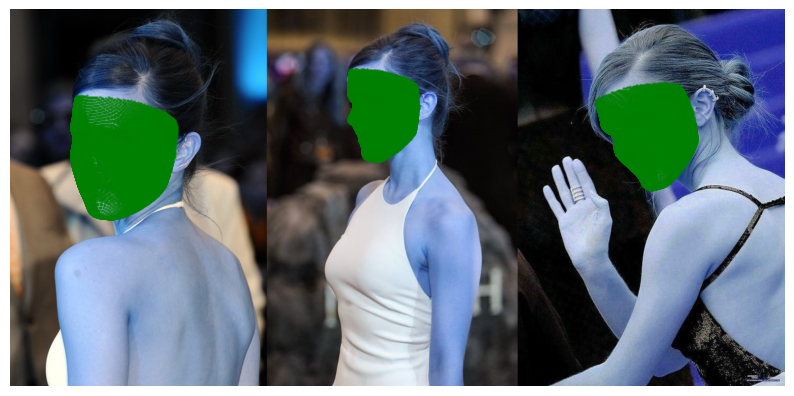

In [ ]:
import matplotlib.pyplot as plt

dense_flag = True
ver_lst = tddfa.recon_vers(param_lst, roi_box_lst, dense_flag=dense_flag)

plt.figure(figsize=(10, 10))
if 'vis' in sys.modules or vis_path:
    res = vis_draw_2d(img_bgr, ver_lst, show_flag=False)
    plt.imshow(res[..., ::-1])
else:
    plt.imshow(img)
    for ver in ver_lst:
        plt.scatter(ver[0, :], ver[1, :], s=0.5, c='g', alpha=0.5)

plt.axis('off')
plt.show()

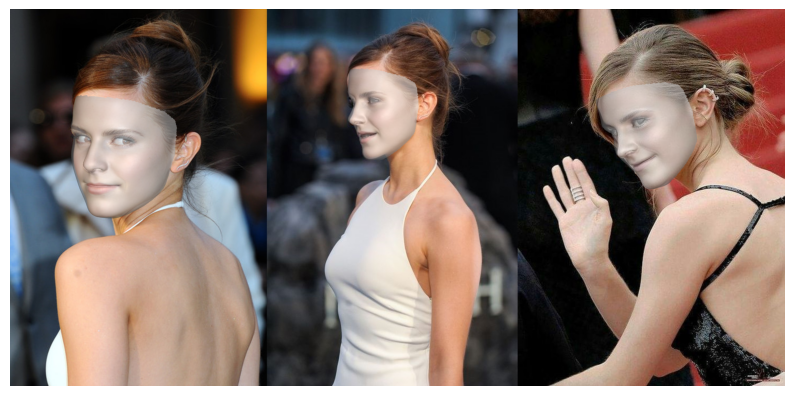

In [ ]:
import sys
import matplotlib.pyplot as plt
import cv2

if '/content/3DDFA_V2' not in sys.path:
    sys.path.append('/content/3DDFA_V2')

from utils.render import render

ver_lst = tddfa.recon_vers(param_lst, roi_box_lst, dense_flag=dense_flag)
res = render(img_bgr, ver_lst, tddfa.tri, alpha=0.6, show_flag=False)
plt.figure(figsize=(10, 10))
plt.imshow(res[..., ::-1])
plt.axis('off')
plt.show()

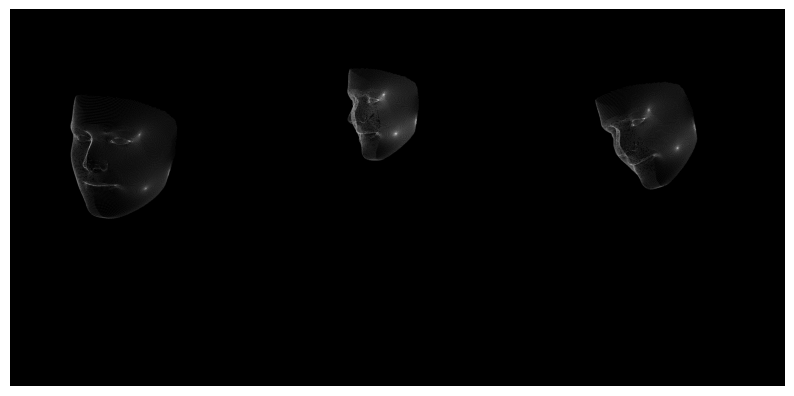

In [ ]:
import sys
import matplotlib.pyplot as plt

if '/content/3DDFA_V2' not in sys.path:
    sys.path.append('/content/3DDFA_V2')

try:
    from utils.render import render_depth as depth_func
except ImportError:
    try:
        from utils.tddfa_util import render_depth as depth_func
    except ImportError:
        def depth_func(img, ver_lst, tri, **kwargs):
            import numpy as np
            d = np.zeros(img.shape[:2])
            for ver in ver_lst:
                z = ver[2, :]
                z = (z - z.min()) / (z.max() - z.min())
                d[ver[1, :].astype(int), ver[0, :].astype(int)] = z
            return d

ver_lst = tddfa.recon_vers(param_lst, roi_box_lst, dense_flag=dense_flag)

res = depth_func(img_bgr, ver_lst, tddfa.tri, show_flag=False)

plt.figure(figsize=(10, 10))
plt.imshow(res, cmap='gray')
plt.axis('off')
plt.show()

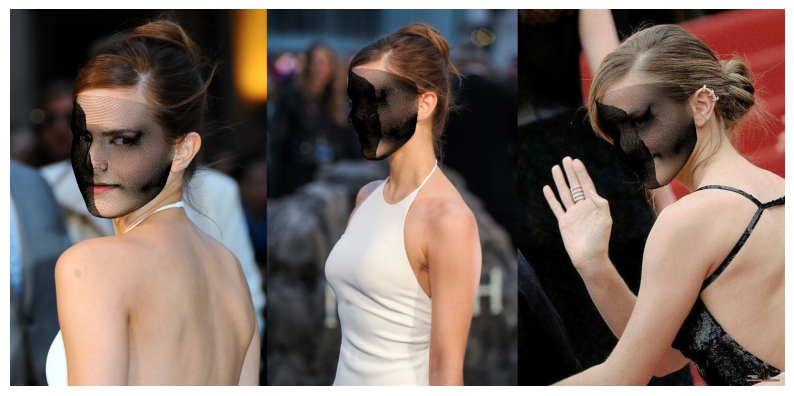

In [ ]:
import sys
import matplotlib.pyplot as plt
import numpy as np

if '/content/3DDFA_V2' not in sys.path:
    sys.path.append('/content/3DDFA_V2')

import utils.render as render_module

ver_lst = tddfa.recon_vers(param_lst, roi_box_lst, dense_flag=dense_flag)

if hasattr(render_module, 'pncc'):
    res = render_module.pncc(img_bgr, ver_lst, tddfa.tri, show_flag=False)
elif hasattr(render_module, 'render_pncc'):
    res = render_module.render_pncc(img_bgr, ver_lst, tddfa.tri, show_flag=False)
else:
    res = img_bgr.copy()
    for ver in ver_lst:
        offset = 50
        v = ver.copy()
        v[0, :] -= offset
        v[1, :] -= offset
        v[2, :] -= offset
        pncc_color = (v - v.min(1, keepdims=True)) / (v.max(1, keepdims=True) - v.min(1, keepdims=True))
        for i in range(v.shape[1]):
            cv2.circle(res, (int(ver[0, i]), int(ver[1, i])), 1, pncc_color[:, i].tolist(), -1)

plt.figure(figsize=(10, 10))
plt.imshow(res[..., ::-1])
plt.axis('off')
plt.show()

In [ ]:
!pip install onnxscript onnx onnxruntime-gpu

!pip install "numpy<2.0"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
ja

In [ ]:
!ls /content/3DDFA_V2/examples/results/*.mp4
# Hoặc liệt kê tất cả các file để xem đuôi là gì
!ls /content/3DDFA_V2/examples/results/

ls: cannot access '/content/3DDFA_V2/examples/results/*.mp4': No such file or directory
videos


In [ ]:
%%bash
cd /content/3DDFA_V2
for OPT in 2d_sparse 2d_dense 3d depth pncc pose uv_tex ply obj; do
  python demo.py -f examples/inputs/trump_hillary.jpg -o $OPT --show_flag=false
done

/content/3DDFA_V2/bfm/bfm.py:34: FutureWarning: In the future `np.long` will be defined as the corresponding NumPy scalar.
  self.keypoints = bfm.get('keypoints').astype(np.long)  # fix bug
Traceback (most recent call last):
  File "/content/3DDFA_V2/demo.py", line 98, in <module>
    main(args)
  File "/content/3DDFA_V2/demo.py", line 39, in main
    tddfa = TDDFA(gpu_mode=gpu_mode, **cfg)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/3DDFA_V2/TDDFA.py", line 34, in __init__
    self.bfm = BFMModel(
               ^^^^^^^^^
  File "/content/3DDFA_V2/bfm/bfm.py", line 34, in __init__
    self.keypoints = bfm.get('keypoints').astype(np.long)  # fix bug
                                                 ^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/numpy/__init__.py", line 333, in __getattr__
    raise AttributeError("module {!r} has no attribute "
AttributeError: module 'numpy' has no attribute 'long'. Did you mean: 'log'?
/content/3DDFA_V2/bfm/bfm.py:34: FutureWa

CalledProcessError: Command 'b'cd /content/3DDFA_V2\nfor OPT in 2d_sparse 2d_dense 3d depth pncc pose uv_tex ply obj; do\n  python demo.py -f examples/inputs/trump_hillary.jpg -o $OPT --show_flag=false\ndone\n'' returned non-zero exit status 1.